In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme()

%config InlineBackend.figure_format = 'svg'

In [8]:
def freq_plot():
    plt.xscale("log")
    plt.xticks(
        [60, 100, 230, 500, 1100, 2400, 5400, 12000],
        ["60", "100", "230", "500", "1.1k", "2.4k", "5.4k", "12k"],
    )

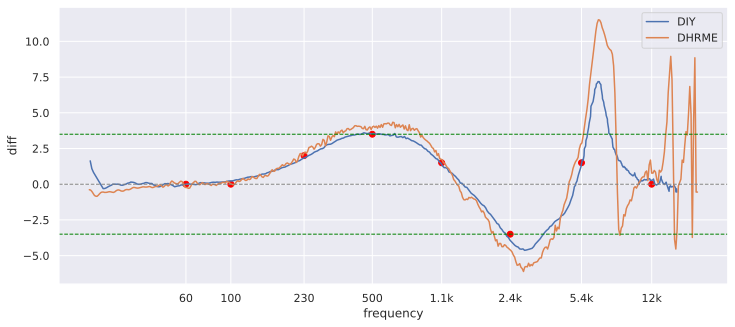

In [ ]:
df_main = pd.read_csv("../measurements/diy/main.csv", sep=";", decimal=",")
df_studio = pd.read_csv("../measurements/diy/studio.csv", sep=";", decimal=",")

# The frequencies do not match, so we need to interpolate the values
df = pd.merge(df_main, df_studio, on="frequency", how="outer").sort_values("frequency")
df["raw_x"] = df["raw_x"].interpolate()
df["raw_y"] = df["raw_y"].interpolate()
df["diff"] = df["raw_x"] - df["raw_y"]

# Either the microphone cannnot measure these frequencies, or the Fairbuds do not produce them
df = df[(df["frequency"] <= 16000) & (df["frequency"] > 20)]
df["diff"] = df["diff"]

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="frequency", y="diff", label="DIY")

df = df.sort_values("frequency").reset_index(drop=True)

df["raw"] = df["diff"]
df = df.round(2)
df[["frequency", "raw"]].dropna().to_csv(
    "../signatures/diy.csv", index=False, float_format="%.2f"
)

df_dhrme = pd.read_csv("../signatures/dhrme.csv")
df_dhrme["raw"] = df_dhrme["raw"] * 1.25
sns.lineplot(data=df_dhrme, x="frequency", y="raw", label="DHRME")
freq_plot()

# Add manually measured points
plt.scatter(
    [60, 100, 230, 500, 1100, 2400, 5400, 12000],
    [0, 0, 2, 3.5, 1.5, -3.5, 1.5, 0],
    color="red",
    label="Measured Points",
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axhline(3.5, color="green", linestyle="--", linewidth=1)
plt.axhline(-3.5, color="green", linestyle="--", linewidth=1)
plt.show()


,frequency,type,value
0,20.20,raw_x,-69.03
1,20.57,raw_x,-68.96
2,20.96,raw_x,-68.81
3,21.35,raw_x,-68.66
4,21.74,raw_x,-68.51
...,...,...,...
905,15512.68,raw_y,-63.03
906,15762.93,raw_y,-63.02
907,15801.79,raw_y,-63.01
908,15948.36,raw_y,-63.45


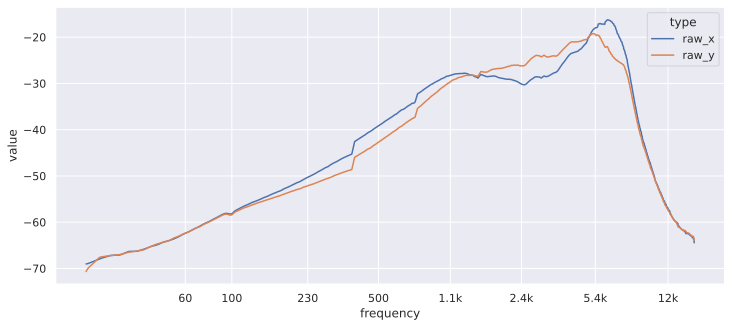

In [10]:
df = df.melt(id_vars="frequency", value_vars=["raw_x", "raw_y"], var_name="type", value_name="value")

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="frequency", y="value", hue="type")
freq_plot()
df
